# SWAP and Fredkin (Controlled-SWAP) Gates
Multi-qubit gates can be used to route and exchange quantum information. Unlike gates that conditionally flip states (like CNOT or Toffoli), the SWAP and Fredkin gates focus on moving state information between qubits.
---## 1. The SWAP Gate
As the name implies, the SWAP gate exchanges the quantum states of two distinct qubits.
### Key Concepts*   **State Exchange:**
Given two qubits in an arbitrary state $|\psi_1\rangle$ and $|\psi_2\rangle$, the SWAP gate maps the joint state $|\psi_1\rangle \otimes |\psi_2\rangle \rightarrow |\psi_2\rangle \otimes \vert\psi_1\rangle$.*   **Information Transfer:** It swaps the **state** information itself, not the physical qubits or hardware channels.*   **Circuit Representation:** Shown as two $X$ marks on the participating qubits connected by a vertical line.




<div style="font-family: monospace; font-size: 1.5em; line-height: 1.0; margin-left: 80px;">
q0 ───<span style="color:#2B6CB0; font-weight:bold;">✕</span>───<br>
      <span style="color:#2B6CB0; font-weight:bold;">│</span><br>
q1 ───<span style="color:#2B6CB0; font-weight:bold;">✕</span>───
</div>


### Matrix Representation & Behavior
In the standard $2$-qubit computational basis ($\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$):

$$\text{SWAP} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

*   **Identical States ($|00\rangle, |11\rangle$):** Swapping identical states has no physical effect. The matrix entries ($1$ in top-left, $1$ in bottom-right) preserve these vectors.
*   **Differing States ($|01\rangle, |10\rangle$):** When the qubits are in different states, the middle portion of the matrix acts to swap the internal amplitudes ($|01\rangle \leftrightarrow |10\rangle$).

---

## 2. The Fredkin (Controlled-SWAP) Gate

The Fredkin gate adds a layer of conditional logic to the standard swap operation, turning it into a three-qubit gate.

### Key Concepts
*   **Operation:** Conditionally swaps the state of two target qubits **if and only if** the control qubit is in the $|1\rangle$ state.
*   **Abbreviation:** Often abbreviated as **CSWAP**.
*   **Circuit Representation:** Indicated by a small solid dot on the control qubit, connected to two $X$ marks on the target qubits.


<div style="font-family: monospace; font-size: 1.5em; line-height: 1.1; margin-left: 80px;">
q0 ───────<span style="color:#6B46C1; font-weight:bold;">●</span>───────<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color:#6B46C1; font-weight:bold;">│</span><br>
q1 ───────<span style="color:#6B46C1; font-weight:bold;">✕</span>───────<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<span style="color:#6B46C1; font-weight:bold;">│</span><br>
q2 ───────<span style="color:#6B46C1; font-weight:bold;">✕</span>───────
</div>

### Matrix Representation & Behavior

In the standard $3$-qubit computational basis ($\{|000\rangle, |010\rangle, \dots, |111\rangle\}$) where the first qubit acts as the control:

$$\text{CSWAP} = \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}$$

*   **Control is $|0\rangle$ ($6 \times 6$ Top-Left):** Resembles an identity matrix. If the first qubit is $0$, nothing happens to the remaining system state.
*   **Control is $|1\rangle$ ($2 \times 2$ Bottom-Right):** Resembles a classic SWAP matrix embedded at the end. It actively swaps the states of the target qubits (specifically mapping $|101\rangle \leftrightarrow |110\rangle$).



In [28]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

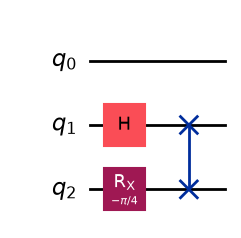

In [29]:
circuit = QuantumCircuit(3)
circuit.h(1)
circuit.rx(-pi/4,2)
circuit.swap(1, 2)# Swap Gate
circuit.draw(output='mpl')

In [30]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

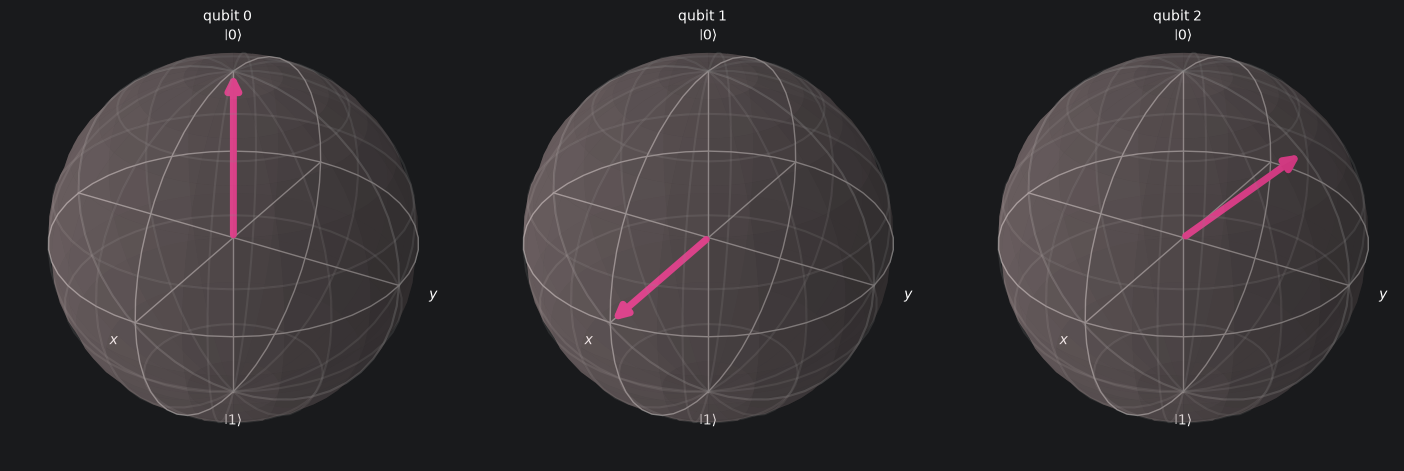

In [31]:
plot_bloch_multivector(statevector)

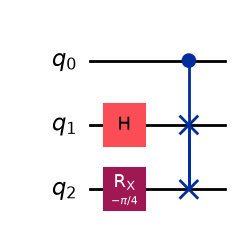

In [32]:
circuit = QuantumCircuit(3)
circuit.h(1)
circuit.rx(-pi/4,2)
circuit.cswap(0, 1, 2)# Fredkin Gate
circuit.draw(output='mpl')

In [33]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

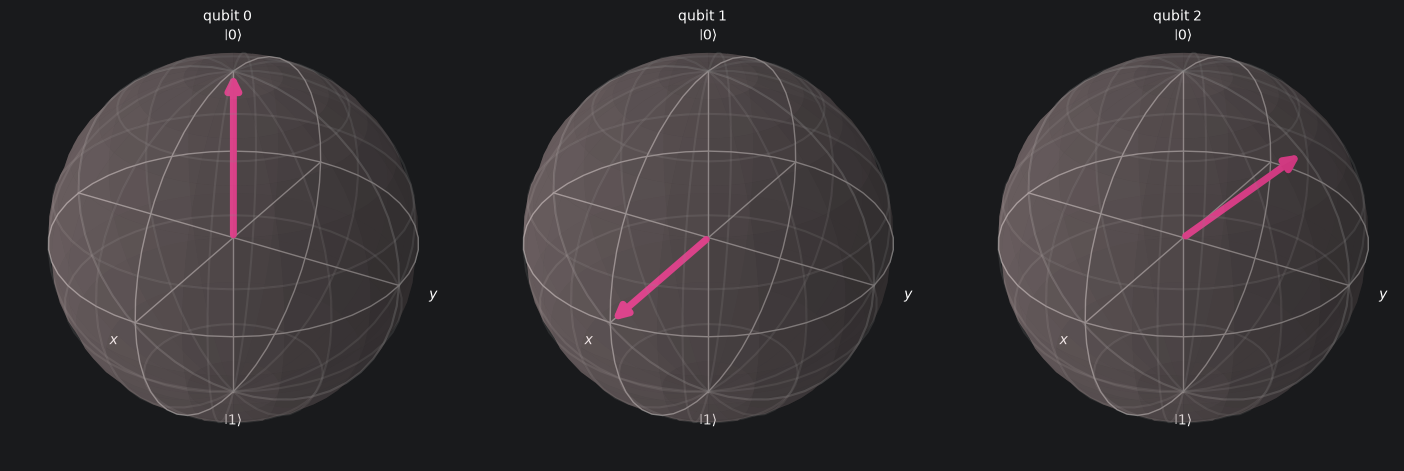

In [34]:
plot_bloch_multivector(statevector)

Since the control qubit is 0, the second and third qubits are not swapped.

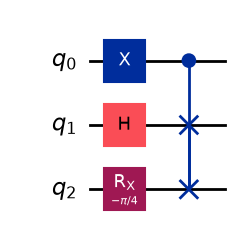

In [35]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.h(1)
circuit.rx(-pi/4,2)
circuit.cswap(0, 1, 2)# Fredkin Gate
circuit.draw(output='mpl')

In [36]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

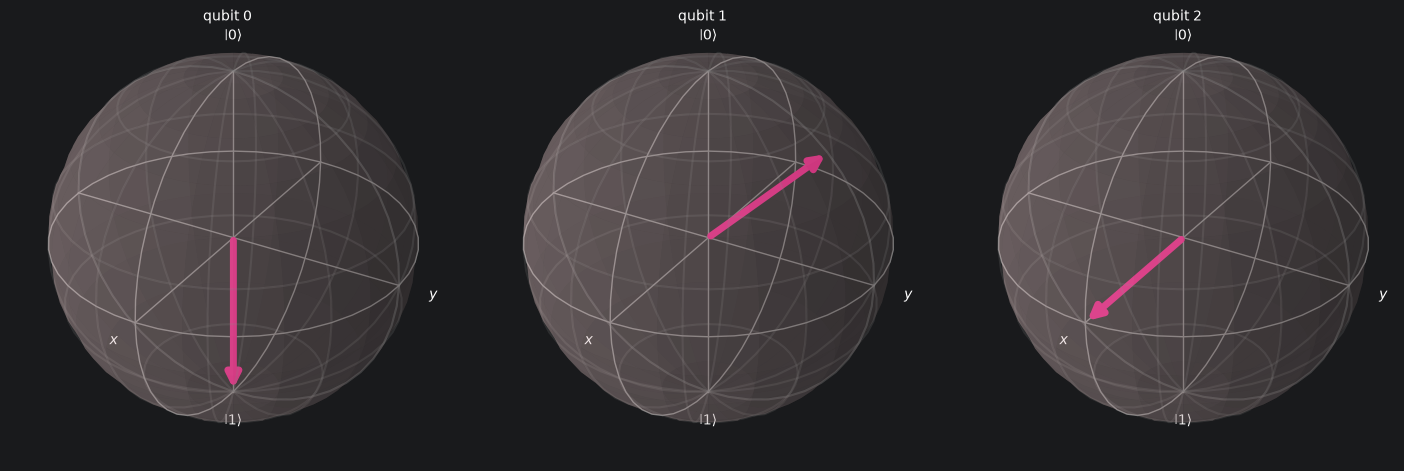

In [37]:
plot_bloch_multivector(statevector)

Now we can see the X gate applied to q(0) at the beginning, and since the control is 1, the Fredkin gate swaps the other two qubits.